# Regional Mean Thermal Forcing and PDS Profiles

This notebook calculates the thermal forcing component of the melt paramaterisation profiles near glaciers and at fjord mouths using OMG CTD data that has been converted to absolute salinity and conservative temperature using the Gibbs Mean Seawater (GSW) TEOS-10 toolkit in python.

The workflow:
1. Load matched CTD profile metadata
2. Extract descent-phase temperature and salinity profiles
3. Calculate thermal forcing 
4. Bin profiles by depth
5. Calculate regional averages
6. Calculate Percent Difference in Submarine melt rate (PDS)
7. Plot regional TF and PDS profiles, with error defined as $\pm$ 1 standard deviation.

In [1]:
## import required libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gsw
import netCDF4 as nc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.close('all')

In [2]:
## Define file paths
#nc_path = r"C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Working_data\OMG_data\GSW_CTDs_v3"
#csv_file = r"C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Working_data\OMG_data\greenland\matched_ng_mouth_with_metadata.csv"
#output_dir = r"C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Results\thermalForcing"
#data_dir = r"C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Working_data\OMG_data\greenland"

In [3]:
# Define file paths from config file 
from config_loader import load_paths

# Load all base paths
paths = load_paths()

csv_dir = paths["csv_dir"]
nc_dir = paths["nc_dir"]
results_root = paths["results_dir"]

# Script-specific output folder for plots
output_dir = results_root / "thermalForcing"
output_dir.mkdir(parents=True, exist_ok=True)

# Script-specific CSV file
csv_file = csv_dir / "matched_ng_mouth_with_metadata.csv"

## Define input and output paths

- `nc_dir`: location of CTD NetCDF files  
- `csv_file`: contains matched near-glacier and fjord mouth profiles  
- `output_dir`: directory where figures will be saved

In [4]:
## Set parameters

max_lag_time = 72
bin_edges = np.arange(0, 1001, 10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
regions = ["NW", "CW", "CE", "SE"]
betas = [1.2, 1.6]

## Set parameters to apply to all profiles

- Maximum allowed time difference between matched profiles is 72 hours
- Depth bins used for vertical averaging (10 m bins from 0-1000 m) to put all profiles on a global grid.
- Regions included in the study
- β exponents used for TF sensitivity

In [5]:
## Isolate the downcast
def isolate_descent_phase(depth, data): 
    deepest_index = np.argmax(depth) 
    return depth[:deepest_index+1], data[:deepest_index+1] 

## Isolate the downcast profile
Some profiles still retain the upcast, so we identify the deepest point as the end of the downcast, and slice just this first section of the profile. Everything after the deepest point is removed.



In [6]:
# Load and clean csv data 
df = pd.read_csv(csv_file)
df = df.dropna(subset=["ng_filename", "mouth_filename"])
df = df[~df['icepicks_id'].isin(["1(2019)", "152(2019)"])]
df["time_difference_hours"] = pd.to_numeric(df["time_difference_hours"], errors="coerce")
df_filtered = df[df["time_difference_hours"].abs() <= max_lag_time].copy()
print(f"Filtered to {len(df_filtered)} profiles with lag time <= {max_lag_time} hrs")


Filtered to 59 profiles with lag time <= 72 hrs


## Load csv that matches fjord CTD profiles and contains auxiliary data
Profiles are filtered to ensure:

- Both near-glacier and fjord mouth casts exist
- Profiles are not flagged for removal. Fjords 1(2019) and 152(2019) are poor quality.
- Time difference between casts ≤ 72 hours

In [7]:
## Process each profile pair to compute TF and PDS

TF_profiles = {} # Store thermal forcing profiles for each profile pair
PDS_profiles = {} # Store PDS profiles for each profile pair
pds_rows = [] # List to store rows of data for the final PDS profiles DataFrame

for i, row in df_filtered.iterrows():
    ng_filename = row["ng_filename"] # Get the ng_filename from the current row
    mouth_filename = row["mouth_filename"] # Get the mouth_filename from the current row
    data = {} # Dictionary to store depth, temp, salt, and latitude for ng and mouth profiles

    try:
        for label, filename in zip(["ng", "mouth"], [ng_filename, mouth_filename]): #loop through ng and mouth profiles
            file_path = os.path.join(nc_dir, filename) # construct the full file path for each .nc file by appending the filename listed in the csv to the base path where the .nc files are stored
            with nc.Dataset(file_path, "r") as dataset:
                depth = np.squeeze(dataset.variables["depth"][:]) # read the each variable from the .nc file and remove any singleton dimensions
                temp = np.squeeze(dataset.variables["conservative_temperature"][:])
                salt = np.squeeze(dataset.variables["absolute_salinity"][:])

                lat = 70.0
                if "latitude" in dataset.variables: # get latitude from the .nc file if it exists, otherwise default to 70.0
                    lat = float(np.squeeze(dataset.variables["latitude"][:]))
                elif "lat" in dataset.variables:
                    lat = float(np.squeeze(dataset.variables["lat"][:]))

                d_depth, d_temp = isolate_descent_phase(depth, temp) # call helper function to isolate the downcast for each profile
                _, d_salt = isolate_descent_phase(depth, salt) 

                valid = d_temp <= 50 # filter out erroneous temperature values greater than 50°C
                d_depth = d_depth[valid]
                d_temp = d_temp[valid]
                d_salt = d_salt[valid]

                data[label] = (d_depth, d_temp, d_salt, lat)
    except Exception as e:
        print(f"Error loading profiles: {e}")
        continue

    # unpack variables from the data dictionary     
    ng_depth, ng_temp, ng_salt, ng_lat = data["ng"] 
    mouth_depth, mouth_temp, mouth_salt, mouth_lat = data["mouth"]

    #find the overlapping depth range between the ng and mouth profiles
    common_min = max(min(ng_depth), min(mouth_depth)) 
    common_max = min(max(ng_depth), max(mouth_depth)) # identify the max depth of the shallower profile
    if common_min >= common_max: # if there is no overlapping depth range, skip this profile pair
        continue
    
    # get pressure from depth and latitude using GSW, then calculate the freezing temperature for each profile
    p_ng = gsw.p_from_z(-ng_depth, ng_lat) #
    p_mouth = gsw.p_from_z(-mouth_depth, mouth_lat)

    # Calculate the conservative temperature version of the freezing temperature 
    Tf_ng = gsw.CT_freezing(ng_salt, p_ng, 0) # use gsw.CT_freezing because we use conservative temperature. 
    Tf_mouth = gsw.CT_freezing(mouth_salt, p_mouth, 0)

    # Calculate thermal forcing (T-Tf) for each profile
    TF_ng = ng_temp - Tf_ng
    TF_mouth = mouth_temp - Tf_mouth
    
    # Get the grounding line depth from the metadata for this glacier
    # If the column doesn't exist or the value is missing, return NaN
    grounding_depth = row.get("grounding_line_depth", np.nan)

    # If the grounding line depth is NaN (missing in the dataset),
    # fall back to the maximum depth shared by both CTD profiles
    # so that binning only uses depths where both profiles overlap

    if np.isnan(grounding_depth):
        grounding_depth = common_max
    
    # Determine which depth bins are shallower than or equal to
    # the grounding line depth. Only these bins will be used in
    # the TF calculations to avoid including water deeper than
    # the glacier grounding line.
    valid_bins = bin_centers <= grounding_depth
    
    # bin thermal forcing profiles as above
    TF_ng_binned = np.full(len(bin_centers), np.nan)
    TF_mouth_binned = np.full(len(bin_centers), np.nan)

    # Loop through each depth bin
    for j in range(len(bin_edges) - 1):
        
        # Skip this bin if it is deeper than the allowed depth
        # (i.e., deeper than the glacier grounding line depth)
        if not valid_bins[j]:
            continue

        # Create boolean masks identifying data points that fall
        # within the current depth bin for the near-glacier profile
        mask_ng = (ng_depth >= bin_edges[j]) & (ng_depth < bin_edges[j+1])

        # Same mask but for the fjord mouth profile
        mask_mouth = (mouth_depth >= bin_edges[j]) & (mouth_depth < bin_edges[j+1])

        # If there are any near-glacier data points in this bin,
        # calculate the mean thermal forcing for those points
        if np.any(mask_ng):
            TF_ng_binned[j] = np.nanmean(TF_ng[mask_ng])

        # If there are any fjord mouth data points in this bin,
        # calculate the mean thermal forcing for those points
        if np.any(mask_mouth):
            TF_mouth_binned[j] = np.nanmean(TF_mouth[mask_mouth])

    # store the binned TF profiles and region information in the TF_profiles dictionary using the index of the current profile pair as the key
    TF_profiles[i] = {"TF_ng": TF_ng_binned, "TF_mouth": TF_mouth_binned, "region": row["region"].strip().upper()} 

    # calculate PDS using the binned TF profiles and store in the PDS_profiles dictionary
    # use np.errstate to suppress warnings about invalid operations (like division by zero) that can occur when calculating PDS, and set those values to NaN instead of raising an error
    with np.errstate(divide='ignore', invalid='ignore'):
        PDS_high = ((TF_ng_binned**1.6 - TF_mouth_binned**1.6) / TF_mouth_binned**1.6) * 100
        PDS_low  = ((TF_ng_binned**1.2 - TF_mouth_binned**1.2) / TF_mouth_binned**1.2) * 100

    PDS_profiles[i] = {"high": PDS_high, "low": PDS_low}

    # save PDS_profiles as csv file with region and icepicks data

    # Get metadata for this profile pair
    icepicks_id = row["icepicks_id"]              
    region = row["region"].strip().upper()           

    # Loop through each depth bin and corresponding PDS values
    for depth, pdsHi, pdsLo in zip(bin_centers, PDS_high, PDS_low):

        # Skip bins where both PDS values are NaN (no data in that depth bin)
        if np.isnan(pdsHi) and np.isnan(pdsLo):
            continue

        # Append row for beta=1.6 (PDS high) PDS formulation 
        pds_rows.append({
            "icepicks_id": icepicks_id,
            "region": region,
            "depth": depth,
            "PDS_type": "high",
            "PDS": pdsHi
        })

        # Append row for beta=1.2 (PDS low) PDS formulation
        pds_rows.append({
            "icepicks_id": icepicks_id,
            "region": region,
            "depth": depth,
            "PDS_type": "low",
            "PDS": pdsLo
        })

# ------------------------------------------------------------
# Convert the collected rows into a pandas DataFrame
# ------------------------------------------------------------

pds_df = pd.DataFrame(pds_rows)

# Optional: sort for easier inspection
pds_df = pds_df.sort_values(["icepicks_id", "depth", "PDS_type"])

# ------------------------------------------------------------
# Save the long-format PDS table to CSV for later analysis
# ------------------------------------------------------------

output_file = os.path.join(csv_dir, "PDS_profiles.csv")

pds_df.to_csv(output_file, index=False)

print(f"PDS profiles saved to: {output_file}")


PDS profiles saved to: C:\Users\efc4\OneDrive - University of St Andrews\Desktop\PhD\First_Year\Projects\Fjord_Shelf_Observations\Working_data\OMG_data\greenland\PDS_profiles.csv


## Calculate thermal forcing

For each matched profile pair:

1. Load CTD temperature and salinity
2. Isolate the downcast
3. Compute pressure from depth
4. Calculate freezing temperature using TEOS-10
5. Compute thermal forcing (TF): \[
TF = T - T_f
\]



6. Bin TF values from 0-1000 m in 10 m bins.
7. Crop out any values below grounding line depth as melting only occurs above this point
8. For each depth bin, identify all TF values that fall within that depth range.
9. Compute the mean TF for that bin.
10. Store the mean value in a new binned profile.
11. Calculate PDS from the binned TF profiles

## Percent Difference in Submarine melt rate (PDS)

PDS measures the relative difference in melt rate between the near glacier and fjord mouth:

\[
PDS = \frac{TF_{ng}^{\beta} - TF_{mouth}^{\beta}}{TF_{mouth}^{\beta}} \times 100
\]

Two β values are evaluated (see Xu et al, 2013):

- β = 1.2 (high subglacial discharge)
- β = 1.6 (low subglacial discharge)

## Calculate regional mean PDS profiles and StDev


In [8]:
## Calculate regional means

#initialise lists
regional_means = {} # initialise list
regional_pds = {}

for region in regions:
    idxs = [idx for idx, v in TF_profiles.items() if v["region"] == region] # count the number of profiles in the current region.
    if len(idxs) < 3: # only calculate the mean if there are at least 3 profiles in the region, otherwise skip to the next region
        continue
    
    #stack the TF profiles into 2D arrays 
    # Each row is a different profile
    # Each column is a different depth bin
    TF_ng_stack = np.array([TF_profiles[idx]["TF_ng"] for idx in idxs])
    TF_mouth_stack = np.array([TF_profiles[idx]["TF_mouth"] for idx in idxs])
    
    #stack the PDS profiles into 2D arrays
    PDS_high_stack = np.array([PDS_profiles[idx]["high"] for idx in idxs])
    PDS_low_stack  = np.array([PDS_profiles[idx]["low"]  for idx in idxs])
    
    # mask depths where there are less than 3 profiles with which to calculate the mean
    valid = np.sum(~np.isnan(TF_ng_stack), axis=0) >= 3

    # Calculate the regional mean and standard deviation of all TF profiles in the region
    mean_ng = np.nanmean(TF_ng_stack, axis=0)
    std_ng  = np.nanstd(TF_ng_stack, axis=0)
    mean_mouth = np.nanmean(TF_mouth_stack, axis=0)
    std_mouth  = np.nanstd(TF_mouth_stack, axis=0)
    mean_ng[~valid] = np.nan # mask bins that don't contain 3 or more profiles.
    mean_mouth[~valid] = np.nan
    regional_means[region] = {"ng_mean": mean_ng, "ng_std": std_ng,
                              "mouth_mean": mean_mouth, "mouth_std": std_mouth}

    mean_PDShigh = np.nanmean(PDS_high_stack, axis=0)
    std_PDShigh  = np.nanstd(PDS_high_stack, axis=0)
    mean_PDSlow  = np.nanmean(PDS_low_stack, axis=0)
    std_PDSlow   = np.nanstd(PDS_low_stack, axis=0)
    mean_PDShigh[~valid] = np.nan
    mean_PDSlow[~valid] = np.nan
    
    # Store regional TF statistics in a dictionary
    regional_pds[region] = {"PDShigh": mean_PDShigh, "PDSlow": mean_PDSlow,
                             "std_PDShigh": std_PDShigh, "std_PDSlow": std_PDSlow}

C:\Users\efc4\AppData\Local\Temp\ipykernel_12892\4220476232.py:26: RuntimeWarning: Mean of empty slice
  mean_ng = np.nanmean(TF_ng_stack, axis=0)
c:\Users\efc4\Anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\efc4\AppData\Local\Temp\ipykernel_12892\4220476232.py:28: RuntimeWarning: Mean of empty slice
  mean_mouth = np.nanmean(TF_mouth_stack, axis=0)
C:\Users\efc4\AppData\Local\Temp\ipykernel_12892\4220476232.py:35: RuntimeWarning: Mean of empty slice
  mean_PDShigh = np.nanmean(PDS_high_stack, axis=0)
C:\Users\efc4\AppData\Local\Temp\ipykernel_12892\4220476232.py:37: RuntimeWarning: Mean of empty slice
  mean_PDSlow  = np.nanmean(PDS_low_stack, axis=0)


## Regional averaging

Profiles are grouped into four Greenland regions:

- NW
- CW
- CE
- SE

Only depth bins with **at least three profiles** are included.

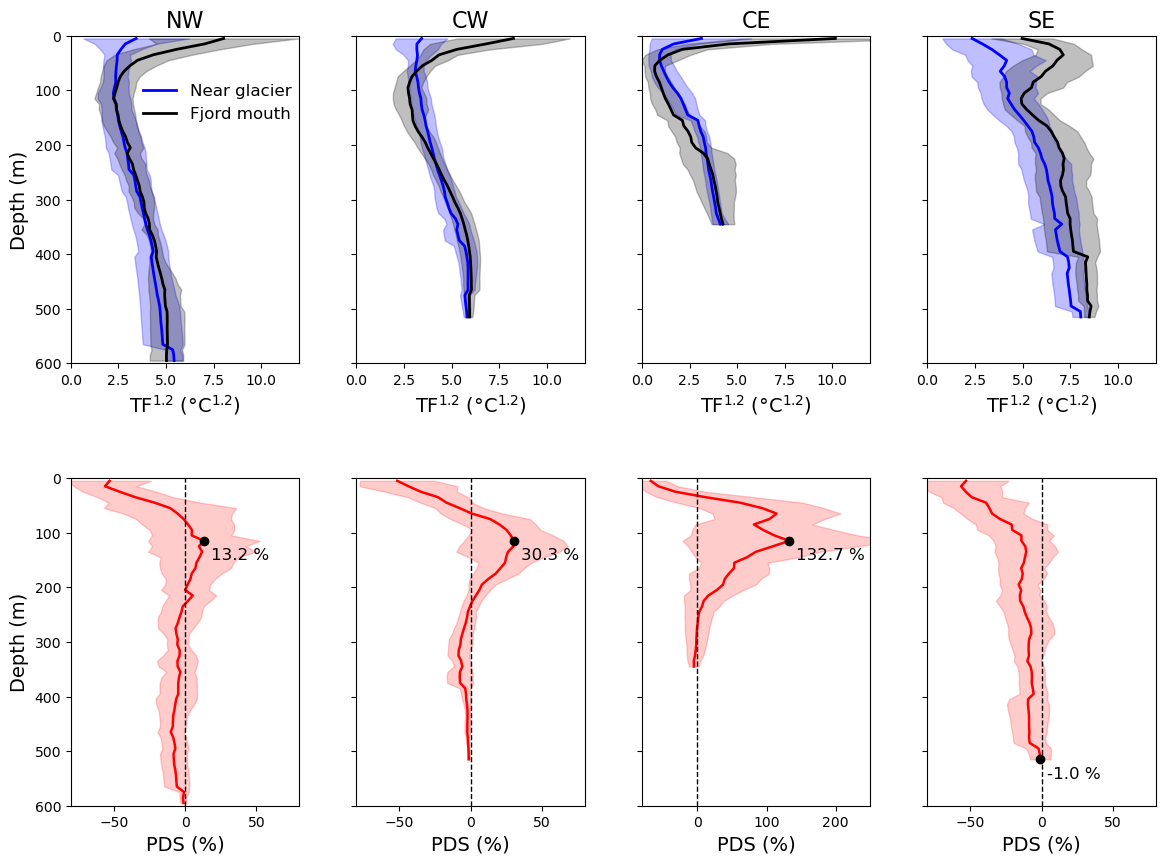

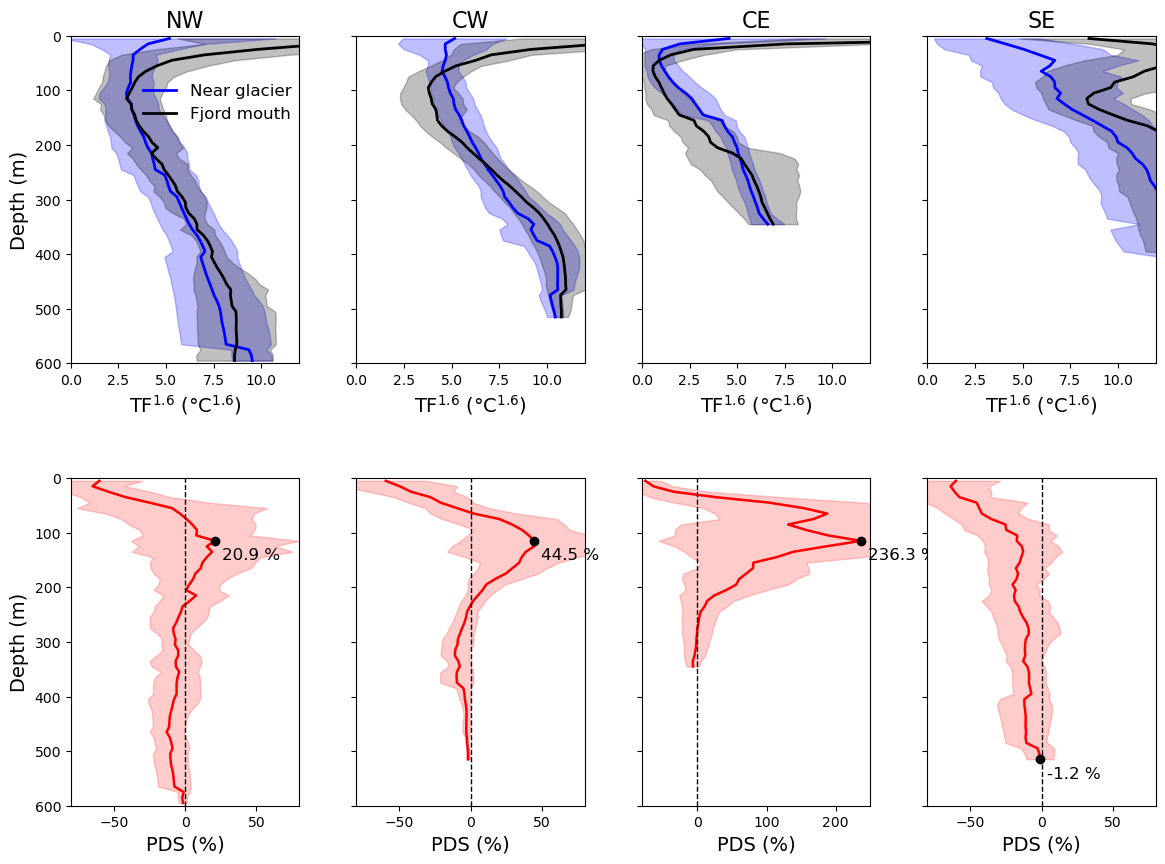

In [9]:
## Plot TF and PDS profiles for each region (2 x 4 subplots)

for beta in betas:

    fig, axes = plt.subplots(2, 4, figsize=(14, 10), sharey=True)

    regions_to_plot = list(regional_means.keys()) 

    for col, region in enumerate(regions_to_plot):
        data = regional_means[region]
        pds  = regional_pds[region]

        # Top row: TF^beta 
        ax_tf = axes[0, col]

        ng_mean  = data["ng_mean"] ** beta
        ng_std   = beta * (data["ng_mean"] ** (beta - 1)) * data["ng_std"]
        mouth_mean = data["mouth_mean"] ** beta
        mouth_std  = beta * (data["mouth_mean"] ** (beta - 1)) * data["mouth_std"]

        ax_tf.plot(ng_mean, bin_centers, color="blue", linewidth=2, label="Near glacier")
        ax_tf.plot(mouth_mean, bin_centers, color="black", linewidth=2, label="Fjord mouth")

        ax_tf.fill_betweenx(bin_centers, ng_mean - ng_std, ng_mean + ng_std, color="blue", alpha=0.25)
        ax_tf.fill_betweenx(bin_centers, mouth_mean - mouth_std, mouth_mean + mouth_std, color="black", alpha=0.25)

        ax_tf.set_ylim(600, 0)
        ax_tf.set_xlim(0, 12)
        ax_tf.set_xlabel(f"TF$^{{{beta}}}$ (°C$^{{{beta}}}$)", fontsize=14)

        if col == 0:
            ax_tf.set_ylabel("Depth (m)", fontsize=14)

        ax_tf.set_title(region, fontsize=16)

        if col == 0:
            ax_tf.legend(fontsize=12, loc="upper right", bbox_to_anchor=(1.03, 0.9), frameon=False)

        # Bottom row: PDS
        ax_pds = axes[1, col]

        if beta == 1.2:
            mean_pds = pds["PDSlow"]
            std_pds  = pds["std_PDSlow"]
        else:
            mean_pds = pds["PDShigh"]
            std_pds  = pds["std_PDShigh"]

        ax_pds.plot(mean_pds, bin_centers, color="red", linewidth=1.8)
        ax_pds.fill_betweenx(bin_centers,
                             mean_pds - std_pds,
                             mean_pds + std_pds,
                             color="red", alpha=0.2)

        ax_pds.axvline(0, color="k", linestyle="--", linewidth=1)

        if np.any(~np.isnan(mean_pds)):
            max_idx = np.nanargmax(mean_pds)
            max_pds = mean_pds[max_idx]
            max_depth = bin_centers[max_idx]

            ax_pds.plot(max_pds, max_depth, 'o', color='black', markersize=6)
            ax_pds.annotate(f"{max_pds:.1f} %",
                            xy=(max_pds, max_depth),
                            xytext=(5, -5),
                            textcoords="offset points",
                            fontsize=12,
                            ha="left", va="top")

        ax_pds.set_ylim(600, 0)

        if region == "CE":
            ax_pds.set_xlim(-80, 250)
        else:
            ax_pds.set_xlim(-80, 80)

        ax_pds.set_xlabel("PDS (%)", fontsize=14)

        if col == 0:
            ax_pds.set_ylabel("Depth (m)", fontsize=14)

    plt.subplots_adjust(wspace=0.25, hspace=0.35)

    plt.savefig(
        os.path.join(output_dir, f"TF_PDS_2x4_beta{beta}.png"),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()


## Plot regional TF and PDS profiles

Each figure shows:

Top row:
- Mean TF^β profiles for near-glacier and fjord mouth waters

Bottom row:
- Percent Difference in Sensitivity (PDS)

Shaded regions represent ±1 standard deviation.